# Дискретно-событийная модель SIR: производительность

В дискретно-событийной модели каждый здоровый человек порождает
событие при каждой встрече, поэтому время счёта растёт вместе
с размером популяции. Измерим его для 10000 человек с помощью
`@benchmark` и посмотрим, как оно зависит от размера популяции.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV, BenchmarkTools

script_name = "sir_des_benchmark"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Подготовка модели

Модель после прогона уже находится в момент `tmax`, и повторный
вызов `sir_run` ничего не делает. Поэтому перед каждым замером
создаётся новая модель.

In [2]:
tmax = 40.0
p = [0.05, 10.0, 0.25]

function prepared_model(n, p)
    m = MakeSIRModel([n - 10, 10, 0], p)
    activate(m)
    return m
end

Random.seed!(1234)

TaskLocalRNG()

## Замер для 10000 человек

Выполняется три замера, каждый на новой модели.

In [3]:
bench = @benchmark sir_run(m, $tmax) setup = (m = prepared_model(10000, $p)) evals = 1 samples = 3 seconds = 600
display(bench)

BenchmarkTools.Trial: 3 samples with 1 evaluation per sample.
 Range (min … max):  4.397 s …    6.161 s  ┊ GC (min … max): 3.27% … 3.29%
 Time  (median):     4.876 s               ┊ GC (median):    2.95%
 Time  (mean ± σ):   5.145 s ± 912.377 ms  ┊ GC (mean ± σ):  3.16% ± 0.21%

  █              █                                         █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  4.4 s          Histogram: frequency by time         6.16 s <

 Memory estimate: 1.15 GiB, allocs estimate: 47866829.

## Зависимость от размера популяции

Для каждого размера популяции выполняется один прогон и замеряется
его время.

In [4]:
function time_run(n, p, tmax)
    m = prepared_model(n, p)
    return @elapsed sir_run(m, tmax)
end

sizes = [1000, 2000, 5000, 10000]
times = [time_run(n, p, tmax) for n in sizes]
df_bench = DataFrame(N = sizes, time_s = round.(times, digits = 3))
CSV.write(datadir("sir_des_benchmark.csv"), df_bench)
println(df_bench)

4×2 DataFrame
 Row │ N      time_s  
     │ Int64  Float64 
─────┼────────────────
   1 │  1000    0.238
   2 │  2000    1.034
   3 │  5000    4.001
   4 │ 10000    5.542


## График

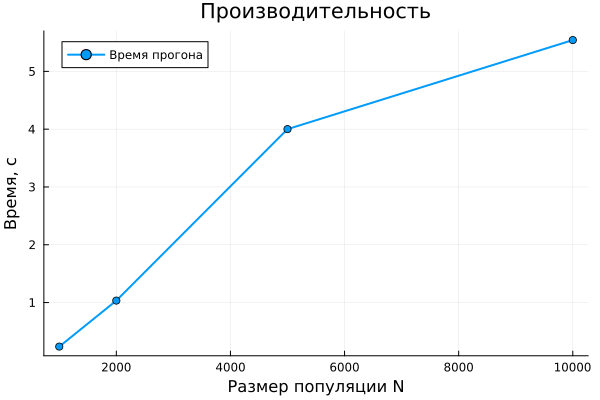

In [5]:
plt_bench = plot(
    df_bench.N,
    df_bench.time_s,
    marker = :circle,
    linewidth = 2,
    label = "Время прогона",
    xlabel = "Размер популяции N",
    ylabel = "Время, с",
    title = "Производительность",
    legend = :topleft,
)
savefig(plt_bench, plotsdir("sir_des_benchmark.png"))
plt_bench